In [1]:
!pip install torch torchvision transformers tqdm

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from transformers import ViTForImageClassification, ViTFeatureExtractor
from tqdm import tqdm

# Data Augmentation and Normalization
train_transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load Dataset
train_dataset = datasets.ImageFolder('/teamspace/studios/this_studio/TransformedTrain/TransformedTrain', transform=train_transform)
test_dataset = datasets.ImageFolder('/teamspace/studios/this_studio/TransformedTest/TransformedTest', transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Load Pretrained ViT Model
model = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224')
model.classifier = nn.Linear(model.config.hidden_size, 4)  # Replace head for 4 classes

# Freeze Pretrained Layers
for param in model.parameters():
    param.requires_grad = False
for param in model.classifier.parameters():
    param.requires_grad = True

# Training Setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Training Loop (Head Only)
for epoch in range(10):  # Train head only
    model.train()
    running_loss = 0.0
    for inputs, labels in tqdm(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs).logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f'Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}')

# Fine-Tune Entire Model
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(model.parameters(), lr=1e-5)
for epoch in range(20):  # Fine-tune
    model.train()
    running_loss = 0.0
    for inputs, labels in tqdm(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs).logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f'Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}')

# Evaluation
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in tqdm(test_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs).logits
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Test Accuracy: {100 * correct / total:.2f}%')

100%|██████████| 1891/1891 [05:38<00:00,  5.58it/s]


Epoch 1, Loss: 0.5687815081988107


100%|██████████| 1891/1891 [02:06<00:00, 14.90it/s]


Epoch 2, Loss: 0.5010045279764991


100%|██████████| 1891/1891 [02:07<00:00, 14.81it/s]


...

Epoch 19, Loss: 0.0016640340341891374


100%|██████████| 1891/1891 [05:01<00:00,  6.28it/s]


Epoch 20, Loss: 0.004190852133337986


100%|██████████| 811/811 [00:51<00:00, 15.88it/s]

Test Accuracy: 99.94%


In [3]:
torch.save(model.state_dict(), '/teamspace/studios/this_studio/ViT_Alzheimer.pth')

In [5]:
import torch
import torch.nn as nn
from transformers import ViTForImageClassification

# Define the model architecture
model = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224')
model.classifier = torch.nn.Linear(model.config.hidden_size, 4)

# Load the saved weights
model.load_state_dict(torch.load('/teamspace/studios/this_studio/ViT_Alzheimer.pth'))

# Move to device and set to evaluation mode
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTSdpaAttention(
            (attention): ViTSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_fe

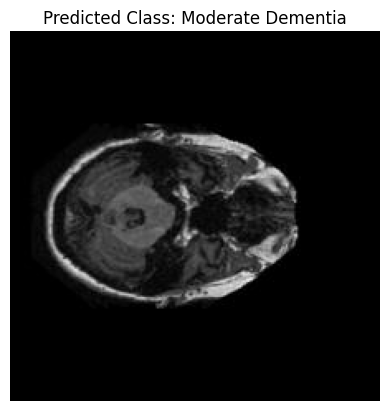

Predicted Class: Moderate Dementia


In [8]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# Load the Trained Model
model = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224')
model.classifier = nn.Linear(model.config.hidden_size, 4)  # Replace head for 4 classes
model.load_state_dict(torch.load('/teamspace/studios/this_studio/ViT_Alzheimer.pth'))  # Load saved weights
model.to(device)
model.eval()  # Set model to evaluation mode

# Define Image Preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to 224x224
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize
])

# Function to Predict Class for a New Image
def predict_image(image_path, model, transform):
    # Load and preprocess the image
    image = Image.open(image_path).convert('RGB')  # Ensure 3 channels (RGB)
    image = transform(image).unsqueeze(0)  # Add batch dimension
    image = image.to(device)

    # Get model prediction
    with torch.no_grad():
        outputs = model(image).logits
        _, predicted = torch.max(outputs, 1)

    # Map predicted class index to class label
    class_labels = ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very Mild Dementia']
    predicted_class = class_labels[predicted.item()]

    return predicted_class

# Test with a New Image
image_path = '/teamspace/studios/this_studio/TransformedTest/TransformedTest/Moderate Dementia/OAS1_0308_MR1_mpr-1_111.jpg'  # Replace with your image path
predicted_class = predict_image(image_path, model, transform)

# Display the Image and Prediction
image = Image.open(image_path)
plt.imshow(image)
plt.title(f'Predicted Class: {predicted_class}')
plt.axis('off')
plt.show()

print(f'Predicted Class: {predicted_class}')